# Solution 2(a): Mandelbrot Set

## Algorithm and Background Theory

The Mandelbrot set is a famous and visually stunning fractal pattern. It can be generated using fixed-point iteration on complex numbers.

To determine if a complex number, $c$, belongs to the set, an iterative calculation is performed starting with $z_0 = 0 + 0j$. The sequence is defined by the formula:
$$ z_{n+1} = z_n^2 + c $$
If the magnitude of $z_n$, or $|z_n|$, diverges in these iterations, then $c$ doesn't belong to the Mandelbrot set. The iteration stops when $|z_n| > 2$.

Generating 1000x1000 Mandelbrot set...
This will take several minutes as it follows the literal instructions.
Progress: 100 / 1000 rows complete
Progress: 200 / 1000 rows complete
Progress: 300 / 1000 rows complete
Progress: 400 / 1000 rows complete
Progress: 500 / 1000 rows complete
Progress: 600 / 1000 rows complete
Progress: 700 / 1000 rows complete
Progress: 800 / 1000 rows complete
Progress: 900 / 1000 rows complete
Progress: 1000 / 1000 rows complete
Data generation complete. Time taken: 5.76 seconds
Plotting...


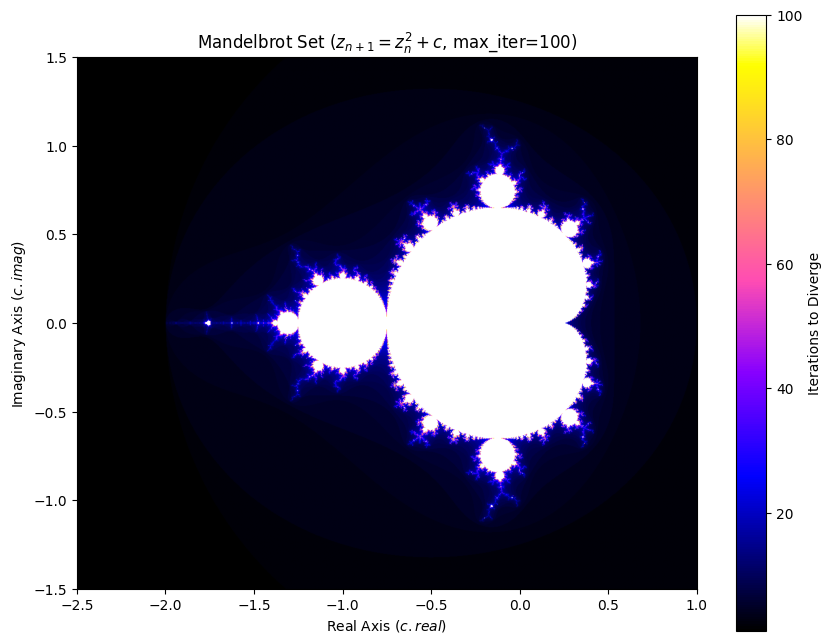

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time

def mandelbrot(c, max_iter=100):
    z = 0 + 0j  # z_0 = 0

    for n in range(max_iter):
        if abs(z) > 2:
            return n

        z = z**2 + c

    return max_iter

WIDTH = 1000
HEIGHT = 1000
X_MIN, X_MAX = -2.5, 1.0
Y_MIN, Y_MAX = -1.5, 1.5
MAX_ITER = 100

x_vals = np.linspace(X_MIN, X_MAX, WIDTH)
y_vals = np.linspace(Y_MIN, Y_MAX, HEIGHT)

mandelbrot_data = np.zeros((HEIGHT, WIDTH), dtype=int)

print(f"Generating {WIDTH}x{HEIGHT} Mandelbrot set...")
print("This will take several minutes as it follows the literal instructions.")
start_time = time.time()

for i in range(HEIGHT):
    for j in range(WIDTH):
        c = x_vals[j] + 1j * y_vals[i]

        mandelbrot_data[i, j] = mandelbrot(c, MAX_ITER)

    if (i+1) % 100 == 0:
        print(f"Progress: {i+1} / {HEIGHT} rows complete")

end_time = time.time()
print(f"Data generation complete. Time taken: {end_time - start_time:.2f} seconds")

print("Plotting...")
plt.figure(figsize=(10, 8))
plt.imshow(mandelbrot_data,
           cmap='gnuplot2',
           extent=[X_MIN, X_MAX, Y_MIN, Y_MAX],
           origin='lower')

plt.colorbar(label="Iterations to Diverge")
plt.title(f"Mandelbrot Set ($z_{{n+1}} = z_n^2 + c$, max_iter={MAX_ITER})")
plt.xlabel("Real Axis ($c.real$)")
plt.ylabel("Imaginary Axis ($c.imag$)")
plt.grid(False)

plt.savefig("mandelbrot_set.png", dpi=300, bbox_inches='tight')


# Solution 2(b): Newton's Fractal

# Algorithm and Background Theory

The Newton-Raphson (NR) method can also be used to generate a fascinating class of fractals known as Newton's fractals. This fractal arises when the NR method is applied over the complex plane, where each initial point $z_0$ is iteratively refined toward one of the roots.

Depending on the starting value, the iteration converges to different roots, forming distinct regions known as basins of attraction. The boundary between these basins exhibits a fractal structure.

Generating 1000x1000 Newton's Fractal...
Progress: 100 / 1000 rows complete
Progress: 200 / 1000 rows complete
Progress: 300 / 1000 rows complete
Progress: 400 / 1000 rows complete
Progress: 500 / 1000 rows complete
Progress: 600 / 1000 rows complete
Progress: 700 / 1000 rows complete
Progress: 800 / 1000 rows complete
Progress: 900 / 1000 rows complete
Progress: 1000 / 1000 rows complete
Data generation complete. Time taken: 38.62 seconds
Plotting...
Plot saved as 'newton_fractal.png'


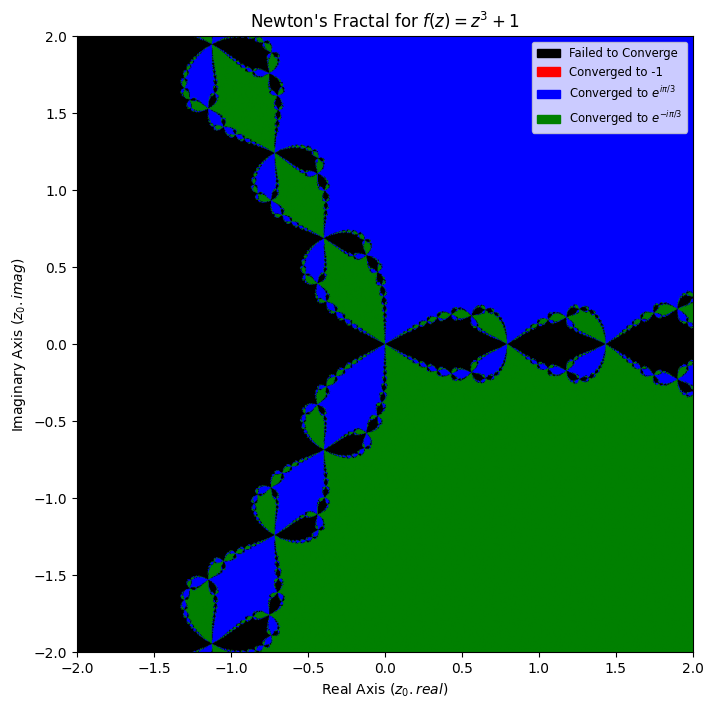

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time
from matplotlib.colors import ListedColormap

def newton_fractal(z0, tol=1e-6):
    root_0 = -1.0 + 0j
    root_1 = np.exp(1j * np.pi / 3)
    root_2 = np.exp(-1j * np.pi / 3)

    z = z0
    max_iter = 100

    for _ in range(max_iter):
        if np.abs(z) < tol:
            return -1

        z_new = z - (z**3 + 1) / (3 * z**2)

        if np.abs(z_new - root_0) < tol:
            return 0

        if np.abs(z_new - root_1) < tol:
            return 1

        if np.abs(z_new - root_2) < tol:
            return 2

        if np.abs(z_new - z) < tol:
            return -1

        z = z_new

    return -1

WIDTH = 1000
HEIGHT = 1000
X_MIN, X_MAX = -2.0, 2.0
Y_MIN, Y_MAX = -2.0, 2.0
TOLERANCE = 1e-6

x_vals = np.linspace(X_MIN, X_MAX, WIDTH)
y_vals = np.linspace(Y_MIN, Y_MAX, HEIGHT)

fractal_data = np.zeros((HEIGHT, WIDTH), dtype=int)

print(f"Generating {WIDTH}x{HEIGHT} Newton's Fractal...")
start_time = time.time()

for i in range(HEIGHT):
    for j in range(WIDTH):
        z0 = x_vals[j] + 1j * y_vals[i]
        fractal_data[i, j] = newton_fractal(z0, TOLERANCE)

    if (i+1) % 100 == 0:
        print(f"Progress: {i+1} / {HEIGHT} rows complete")

end_time = time.time()
print(f"Data generation complete. Time taken: {end_time - start_time:.2f} seconds")

print("Plotting...")
plt.figure(figsize=(9, 8))

colors = ['black', 'red', 'blue', 'green']
cmap = ListedColormap(colors)

plt.imshow(fractal_data,
           cmap=cmap,
           extent=[X_MIN, X_MAX, Y_MIN, Y_MAX],
           origin='lower')

c_patches = [plt.Rectangle((0, 0), 1, 1, color=colors[i]) for i in range(len(colors))]
labels = ['Failed to Converge', 'Converged to -1', r'Converged to $e^{i\pi/3}$', r'Converged to $e^{-i\pi/3}$']
plt.legend(c_patches, labels, loc='upper right', fontsize='small')

plt.title(f"Newton's Fractal for $f(z) = z^3 + 1$")
plt.xlabel("Real Axis ($z_0.real$)")
plt.ylabel("Imaginary Axis ($z_0.imag$)")
plt.grid(False)

plt.savefig("newton_fractal.png", dpi=300, bbox_inches='tight')
print("Plot saved as 'newton_fractal.png'")


# Solution 2(c): Logistic Map and the Onset of Chaos

# Algorithm and Background Theory

The logistic map is a simple yet powerful model that illustrates how complex, chaotic behavior can arise from a deterministic nonlinear system. It was first introduced as a population model.

It is defined recursively by:
 $$x_{n+1}=Ax_{n}(1-x_{n})$$
where A is a control parameter". "For small values of A, the sequence $\{x_{n}\}$ settles to a stable fixed point. As A increases, the system undergoes successive period-doubling bifurcations" and eventually "becomes chaotic.

A key quantity that characterizes chaotic dynamics is the Lyapunov exponent... which measures the average exponential rate at which nearby trajectories diverge. For this map, $f(x) = Ax(1-x)$, so $f'(x) = A - 2Ax$. The finite-time Lyapunov exponent is:
$$\lambda_{n}=\frac{1}{n}\sum_{k=0}^{n-1}\ln|f^{\prime}(x_{k})|$$
A positive Lyapunov exponent indicates sensitive dependence on initial conditions, the defining feature of chaotic behavior.

Generating Bifurcation Diagram...
Bifurcation diagram saved. Time: 0.61s

Calculating Lyapunov Exponent...
Lyapunov exponent for large n (n=1000): 1.357277
Lyapunov exponent plot saved. Time: 0.38s


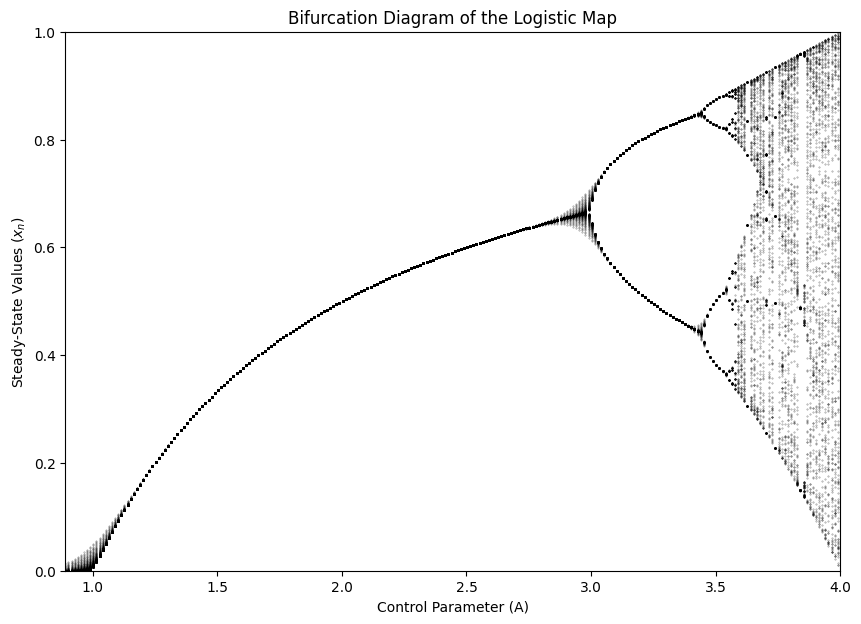

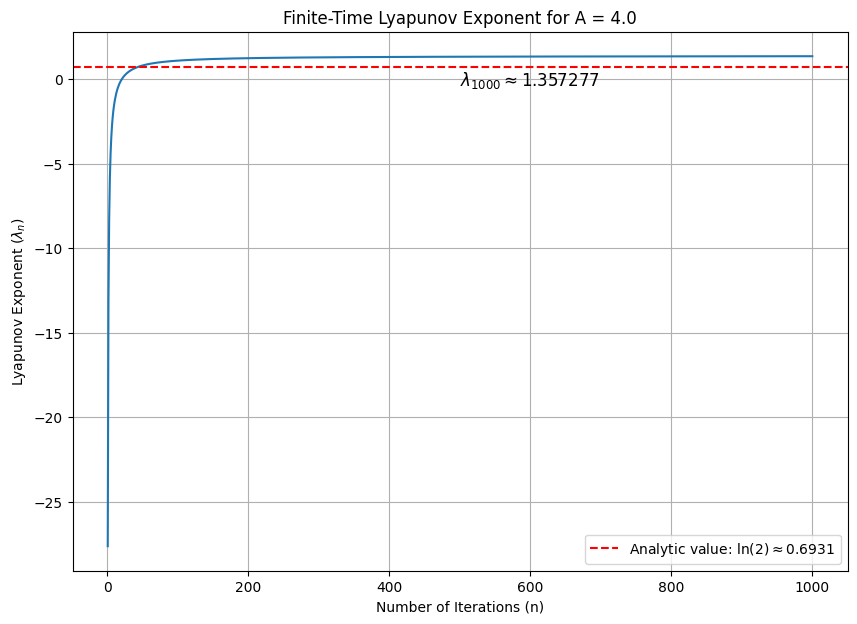

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time

def logistic_map(A, x0, n_iter):
    x_n = np.zeros(n_iter)
    x = x0
    for n in range(n_iter):
        x = A * x * (1 - x)
        x_n[n] = x

    return x_n

print("Generating Bifurcation Diagram...")
start_time = time.time()
A_values = np.arange(0.89, 3.995, 0.0125)
n_iter = 200
n_discard = 15
x0 = 0.5

plot_A = []
plot_x_n = []

for A in A_values:
    x_sequence = logistic_map(A, x0, n_iter)

    final_values = x_sequence[n_discard:]

    for x_n_val in final_values:
        plot_A.append(A)
        plot_x_n.append(x_n_val)

plt.figure(figsize=(10, 7))
plt.scatter(plot_A, plot_x_n, s=0.1, alpha=0.5, c='black')

plt.title("Bifurcation Diagram of the Logistic Map")
plt.xlabel("Control Parameter (A)")
plt.ylabel("Steady-State Values ($x_n$)")
plt.xlim(0.89, 4.0)
plt.ylim(0, 1)
plt.grid(False)

plt.savefig("bifurcation_diagram.png", dpi=300, bbox_inches='tight')
print(f"Bifurcation diagram saved. Time: {time.time() - start_time:.2f}s")
print("\nCalculating Lyapunov Exponent...")
start_time = time.time()

A = 4.0
x0 = 0.5
n_iter = 1000

x_k = logistic_map(A, x0, n_iter)
x_k_with_x0 = np.insert(x_k, 0, x0)

f_prime_x_k = A - 2 * A * x_k_with_x0[:-1]

epsilon = 1e-12
log_f_prime = np.log(np.abs(f_prime_x_k) + epsilon)

cumulative_sum = np.cumsum(log_f_prime)
n_values = np.arange(1, n_iter + 1)
lambda_n = cumulative_sum / n_values #

plt.figure(figsize=(10, 7))
plt.plot(n_values, lambda_n)
plt.axhline(y=np.log(2), color='r', linestyle='--', label=f'Analytic value: $\\ln(2) \\approx {np.log(2):.4f}$', zorder=2)

plt.title(f"Finite-Time Lyapunov Exponent for A = {A}")
plt.xlabel("Number of Iterations (n)")
plt.ylabel(f"Lyapunov Exponent ($\\lambda_n$)")
plt.legend()
plt.grid(True)

lambda_large_n = lambda_n[-1]
print(f"Lyapunov exponent for large n (n={n_iter}): {lambda_large_n:.6f}")
plt.text(0.5, 0.9, f"$\\lambda_{{{n_iter}}} \\approx {lambda_large_n:.6f}$",
         transform=plt.gca().transAxes, fontsize=12)

plt.savefig("lyapunov_exponent.png", dpi=300, bbox_inches='tight')
print(f"Lyapunov exponent plot saved. Time: {time.time() - start_time:.2f}s")